In [ ]:
# Ridge or L2 Reluzatition

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=3.78018e-23): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=3.78018e-21): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=2.63051e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=2.58075e-19): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


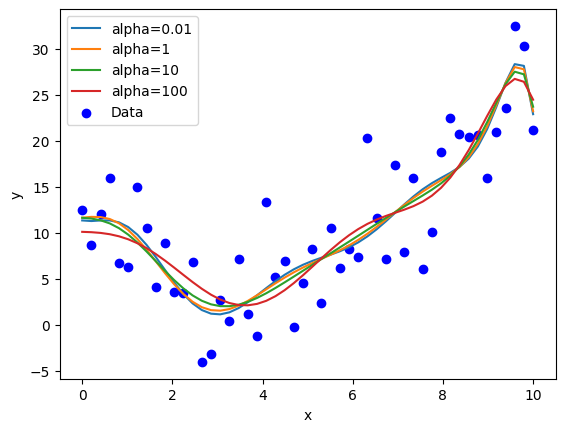

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# nosiy data
np.random.seed(42)
x = np.linspace(0, 10, 50)[:, None]
y = 0.5 *x.squeeze()**2 - 3*x.squeeze() + 10 + np.random.randn(50)*5

alphas = [0.01, 1, 10, 100]

for alpha in alphas:
    model = make_pipeline(PolynomialFeatures(10), Ridge(alpha = alpha))
    model.fit(x, y)
    pre_1 = model.predict(x)
    plt.plot(x, pre_1,  label=f"alpha={alpha}")

# vusliation
plt.scatter(x, y, color="blue", label="Data")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()
    

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=5.29954e-22): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=5.29954e-21): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=5.29954e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


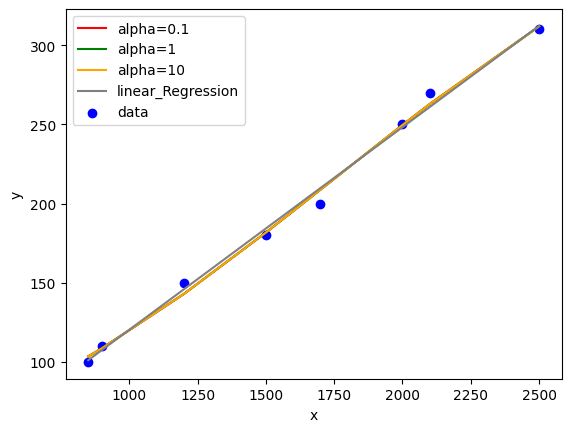

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures


#Date
x = np.array([850, 900, 1200, 1500, 1700, 2000, 2100, 2500]).reshape(-1, 1)
y = np.array([100, 110, 150, 180, 200, 250, 270, 310])

#linear regression fit
model = LinearRegression()
model.fit(x, y)
y_pre = model.predict(x)

#ridge regression 
alphas = [0.1, 1, 10]
colors = ["red", "green", "orange"]

for alpha, color in zip(alphas, colors):
    model_y = make_pipeline(PolynomialFeatures(3),Ridge(alpha=alpha))
    model_y.fit(x, y)
    x_pre = model_y.predict(x)
    plt.plot(x, x_pre,color = color, label = f"alpha={alpha}")

#visulization
plt.plot(x, y_pre, color = "grey", label="linear_Regression")
plt.scatter(x, y, color = "blue", label="data")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


Linear Regression Coefficients:
Slope: 0.12797247355677327
Intercept: -7.70612973110741
----------------------------------------
Ridge Regression (alpha=0.1) Coefficients:
Slope: 0.12797246833806677
Intercept: -7.706121413793909
----------------------------------------
Ridge Regression (alpha=1) Coefficients:
Slope: 0.1279724213697275
Intercept: -7.706046558003209
----------------------------------------
Ridge Regression (alpha=10) Coefficients:
Slope: 0.12797195168823064
Intercept: -7.705298003117576
----------------------------------------


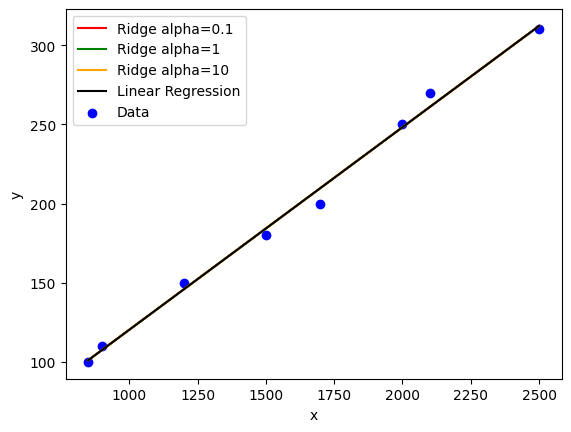

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import make_pipeline

# Data
x = np.array([850, 900, 1200, 1500, 1700, 2000, 2100, 2500]).reshape(-1, 1)
y = np.array([100, 110, 150, 180, 200, 250, 270, 310])

# Linear regression fit
model = LinearRegression()
model.fit(x, y)
y_pre = model.predict(x)

print("Linear Regression Coefficients:")
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)
print("-"*40)

# Ridge regression with different alpha values
alphas = [0.1, 1, 10]
colors = ["red", "green", "orange"]

for alpha, color in zip(alphas, colors):
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(x, y)
    x_pre = ridge_model.predict(x)
    plt.plot(x, x_pre, color=color, label=f"Ridge alpha={alpha}")
    
    print(f"Ridge Regression (alpha={alpha}) Coefficients:")
    print("Slope:", ridge_model.coef_[0])
    print("Intercept:", ridge_model.intercept_)
    print("-"*40)

# Visualization
plt.plot(x, y_pre, color="black", label="Linear Regression")
plt.scatter(x, y, color="blue", label="Data")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

In [ ]:
# House prediction using real world data with Ridge regression

linear RMSE 0.5744898993636633
ridge RMSE 2.9149549236575276


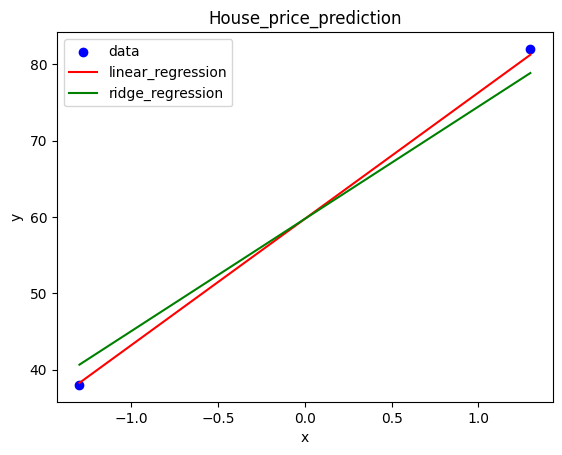

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Data

data = {
    "House_size_sqft" : [800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700],
    "Rooms" : [2, 2, 3, 3, 3, 4, 4, 4, 5, 5],
    "Bedrooms" : [1, 2, 2, 2, 3, 3, 3, 4, 4, 4],
    "Diastance_center_km" : [10, 9, 8, 7, 6, 5, 4, 3, 2, 1],
    "Age_years" : [20, 18, 15, 14, 12, 10, 9, 8, 6, 5],
    "price" : [35, 38, 45, 48, 55, 62, 68, 75, 82, 90]
}

df =pd.DataFrame(data)

x = df["House_size_sqft"].values.reshape(-1, 1)
y = df["price"]

#train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)


#scaling
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)


#linear regression fit

model = LinearRegression()
model.fit(x_train, y_train)
pred_lr = model.predict(x_test)

#ridge regression
ridge = Ridge(alpha = 1)
ridge.fit(x_train, y_train)
pre_ridge = ridge.predict(x_test)

#Rmse
rmse = np.sqrt(mean_squared_error(y_test, pred_lr))
ridge_rmse = np.sqrt(mean_squared_error(y_test, pre_ridge))

print("linear RMSE", rmse)
print("ridge RMSE", ridge_rmse)


# visulization

plt.scatter(x_test, y_test, color = "blue", label = "data")
plt.plot(x_test, pred_lr, color = "red", label = "linear_regression")
plt.plot(x_test, pre_ridge, color = "green", label ="ridge_regression")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("House_price_prediction")
plt.show()

Linear Regression RMSE : 0.7288689868556626
Ridge Regression RMSE  : 1.8319248492543834

Coefficient Comparison:
           Feature  Linear_Coefficient  Ridge_Coefficient
0  House_Size_sqft            6.731456           3.749155
1            Rooms            1.299038           2.958784
2   Location_Score            0.918559           2.894387
3   Nearby_Schools            0.918559           2.894387
4      Distance_km           -6.731456          -3.749155


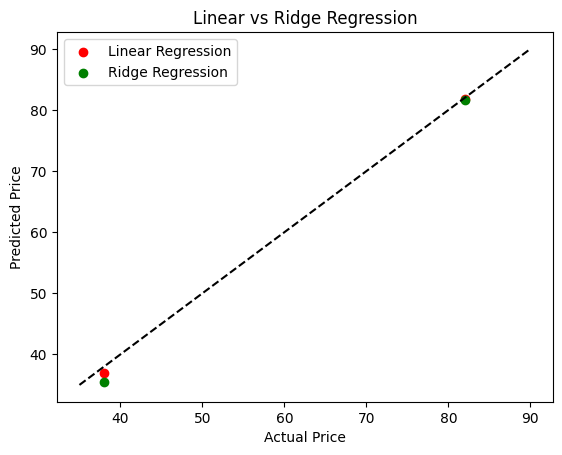

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error

# -----------------------------
# 1. Create Dataset
# -----------------------------
data = {
    "House_Size_sqft": [800,900,1000,1100,1200,1300,1400,1500,1600,1700],
    "Rooms": [2,2,3,3,3,4,4,4,5,5],
    "Location_Score": [6,6,7,7,8,8,9,9,9,10],
    "Nearby_Schools": [1,1,2,2,3,3,4,4,5,5],
    "Distance_km": [10,9,8,7,6,5,4,3,2,1],
    "Price": [35,38,45,48,55,62,68,75,82,90]
}

df = pd.DataFrame(data)

# -----------------------------
# 2. Features & Target
# -----------------------------
X = df.drop("Price", axis=1)
y = df["Price"]

# -----------------------------
# 3. Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 4. Feature Scaling
# -----------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# 5. Linear Regression
# -----------------------------
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

# -----------------------------
# 6. Ridge Regression
# -----------------------------
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
ridge_pred = ridge.predict(X_test_scaled)

# -----------------------------
# 7. Evaluation (RMSE)
# -----------------------------
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))

print("Linear Regression RMSE :", lr_rmse)
print("Ridge Regression RMSE  :", ridge_rmse)

# -----------------------------
# 8. Coefficient Comparison
# -----------------------------
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Linear_Coefficient": lr.coef_,
    "Ridge_Coefficient": ridge.coef_
})

print("\nCoefficient Comparison:")
print(coef_df)

# -----------------------------
# 9. Visualization (Actual vs Predicted)
# -----------------------------
plt.scatter(y_test, lr_pred, color="red", label="Linear Regression")
plt.scatter(y_test, ridge_pred, color="green", label="Ridge Regression")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear vs Ridge Regression")
plt.legend()
plt.show()


In [ ]:
# Salary anlytical

linear cofficent:  0.4954459270865645
ridge cofficent:  0.41727225209835284
predicted_salary: [ 4.7  10.72  3.4 ]


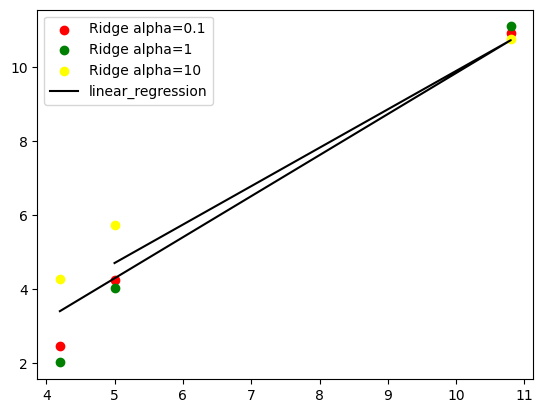

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline

# data

data = {
    "experince_year" : [1, 2, 3, 4, 5,  6, 7, 8],
    "coding_score" : [65, 70, 75, 80, 85, 88, 90, 92],
    "communication" : [60, 65, 70, 75, 80, 83, 85, 88],
    "problem_solving" : [62, 68, 72, 78, 82, 85, 88, 90],
    "salary_lpa" : [ 4.2, 5.0, 6.2, 7.5, 9.0, 10.8, 12.5, 14.0]
}

df = pd.DataFrame(data)

x = df.drop("salary_lpa", axis=1)
y = df["salary_lpa"]

# train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state= 42)

#scaling

scaling = StandardScaler()
x_train_scaling = scaling.fit_transform(x_train)
x_test_scaling = scaling.transform(x_test)

#linear regression

model = LinearRegression()
model.fit(x_train_scaling, y_train)
lin_pre = model.predict(x_test_scaling)

# ridge regression

alphas =[0.1, 1, 10]
colors =["red", "green", "yellow"]

for alpha, color in zip(alphas, colors):
    ridge = Ridge(alpha=alpha)
    ridge.fit(x_train_scaling, y_train)
    rid_pre = ridge.predict(x_test_scaling)
    
    plt.scatter(y_test, rid_pre, color=color, label=f"Ridge alpha={alpha}")

#RMSE

rmse_linear = np.sqrt(mean_squared_error(y_test, lin_pre))
rmse_ridge = np.sqrt(mean_squared_error(y_test, rid_pre))

print("linear cofficent: ", rmse_linear)
print("ridge cofficent: ", rmse_ridge)
print("predicted_salary:",lin_pre)

#visulation
plt.plot( y_test, lin_pre, color="black", label="linear_regression")
plt.legend()
plt.show()

Linear RMSE: 0.4954459270865645
Ridge RMSE (alpha=0.1): 1.100005906841449
Ridge RMSE (alpha=1): 1.3901947132394068
Ridge RMSE (alpha=10): 0.41727225209835284


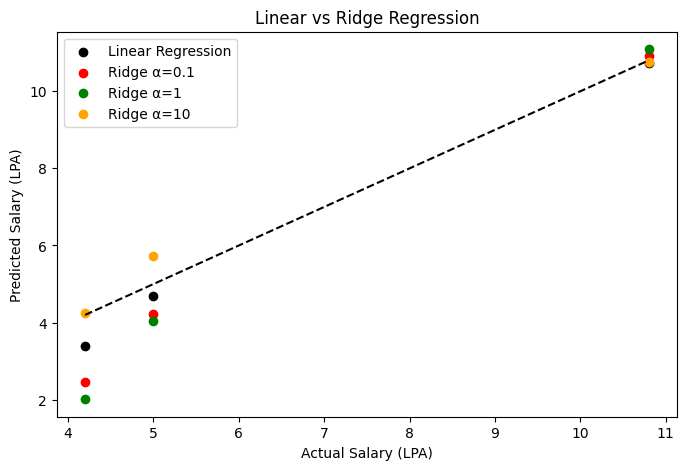

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# ------------------
# Data
# ------------------
data = {
    "experience_year": [1, 2, 3, 4, 5, 6, 7, 8],
    "coding_score": [65, 70, 75, 80, 85, 88, 90, 92],
    "communication": [60, 65, 70, 75, 80, 83, 85, 88],
    "problem_solving": [62, 68, 72, 78, 82, 85, 88, 90],
    "salary_lpa": [4.2, 5.0, 6.2, 7.5, 9.0, 10.8, 12.5, 14.0]
}

df = pd.DataFrame(data)

X = df.drop("salary_lpa", axis=1)
y = df["salary_lpa"]

# ------------------
# Train-Test Split
# ------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ------------------
# Scaling
# ------------------
scaler = StandardScaler()
X_train_scaling = scaler.fit_transform(X_train)
X_test_scaling = scaler.transform(X_test)

# ------------------
# Linear Regression
# ------------------
linear = LinearRegression()
linear.fit(X_train_scaling, y_train)
lin_pre = linear.predict(X_test_scaling)

rmse_linear = np.sqrt(mean_squared_error(y_test, lin_pre))
print("Linear RMSE:", rmse_linear)

# ------------------
# Ridge Regression
# ------------------
alphas = [0.1, 1, 10]
colors = ["red", "green", "orange"]

plt.figure(figsize=(8,5))
plt.scatter(y_test, lin_pre, color="black", label="Linear Regression")

for alpha, color in zip(alphas, colors):
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaling, y_train)
    rid_pre = ridge.predict(X_test_scaling)

    rmse_ridge = np.sqrt(mean_squared_error(y_test, rid_pre))
    print(f"Ridge RMSE (alpha={alpha}):", rmse_ridge)

    plt.scatter(y_test, rid_pre, color=color, label=f"Ridge α={alpha}")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "k--"
)

plt.xlabel("Actual Salary (LPA)")
plt.ylabel("Predicted Salary (LPA)")
plt.title("Linear vs Ridge Regression")
plt.legend()
plt.show()


Linear RMSE: 0.4954459270865645
Ridge RMSEs: {0.1: np.float64(1.100005906841449), 1: np.float64(1.3901947132394068), 10: np.float64(0.41727225209835284)}
Predicted salaries (Linear): [ 4.7  10.72  3.4 ]


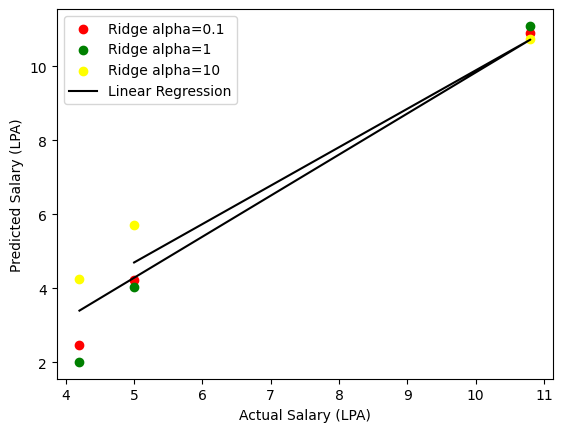

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# data
data = {
    "experince_year": [1, 2, 3, 4, 5, 6, 7, 8],
    "coding_score": [65, 70, 75, 80, 85, 88, 90, 92],
    "communication": [60, 65, 70, 75, 80, 83, 85, 88],
    "problem_solving": [62, 68, 72, 78, 82, 85, 88, 90],
    "salary_lpa": [4.2, 5.0, 6.2, 7.5, 9.0, 10.8, 12.5, 14.0]
}

df = pd.DataFrame(data)

X = df.drop("salary_lpa", axis=1)
y = df["salary_lpa"]

# train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# linear regression
lin_model = LinearRegression()
lin_model.fit(X_train_scaled, y_train)
lin_pred = lin_model.predict(X_test_scaled)

# ridge regression with multiple alphas
alphas = [0.1, 1, 10]
colors = ["red", "green", "yellow"]

rmse_ridge = {}

for alpha, color in zip(alphas, colors):
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    ridge_pred = ridge.predict(X_test_scaled)
    
    # scatter plot
    plt.scatter(y_test, ridge_pred, color=color, label=f"Ridge alpha={alpha}")
    
    # calculate RMSE for each alpha
    rmse_ridge[alpha] = np.sqrt(mean_squared_error(y_test, ridge_pred))

# RMSE
rmse_linear = np.sqrt(mean_squared_error(y_test, lin_pred))

print("Linear RMSE:", rmse_linear)
print("Ridge RMSEs:", rmse_ridge)
print("Predicted salaries (Linear):", lin_pred)

# visualization
plt.plot(y_test.values, lin_pred, color="black", label="Linear Regression")
plt.xlabel("Actual Salary (LPA)")
plt.ylabel("Predicted Salary (LPA)")
plt.legend()
plt.show()

Linear Regression RMSE: 0.4954459270865645
Ridge RMSE (alpha=0.01): 0.6321567805494096
Ridge RMSE (alpha=0.1): 1.100005906841449
Ridge RMSE (alpha=1): 1.3901947132394068
Ridge RMSE (alpha=10): 0.41727225209835284
Ridge RMSE (alpha=100): 3.3213331212060053


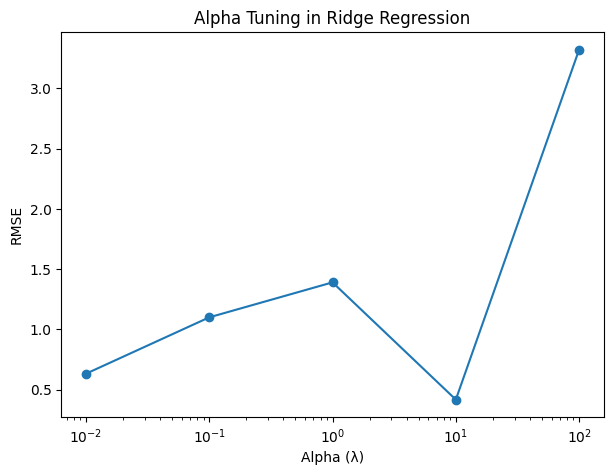

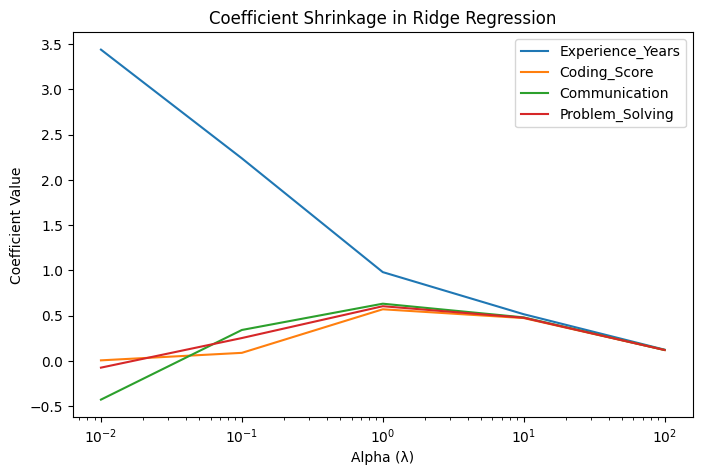

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# -----------------------------
# Dataset
# -----------------------------
data = {
    "Experience_Years": [1, 2, 3, 4, 5, 6, 7, 8],
    "Coding_Score": [65, 70, 75, 80, 85, 88, 90, 92],
    "Communication": [60, 65, 70, 75, 80, 83, 85, 88],
    "Problem_Solving": [62, 68, 72, 78, 82, 85, 88, 90],
    "Salary_LPA": [4.2, 5.0, 6.2, 7.5, 9.0, 10.8, 12.5, 14.0]
}

df = pd.DataFrame(data)

X = df.drop("Salary_LPA", axis=1)
y = df["Salary_LPA"]

# -----------------------------
# Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# -----------------------------
# Feature Scaling
# -----------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# Linear Regression
# -----------------------------
linear = LinearRegression()
linear.fit(X_train_scaled, y_train)
lin_pred = linear.predict(X_test_scaled)

rmse_linear = np.sqrt(mean_squared_error(y_test, lin_pred))
print("Linear Regression RMSE:", rmse_linear)

# -----------------------------
# Ridge Regression (Alpha Tuning)
# -----------------------------
alphas = [0.01, 0.1, 1, 10, 100]
ridge_rmse = []
coefficients = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    pred = ridge.predict(X_test_scaled)
    
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    ridge_rmse.append(rmse)
    coefficients.append(ridge.coef_)
    
    print(f"Ridge RMSE (alpha={alpha}): {rmse}")

# -----------------------------
# Alpha vs RMSE Plot
# -----------------------------
plt.figure(figsize=(7,5))
plt.plot(alphas, ridge_rmse, marker='o')
plt.xscale("log")
plt.xlabel("Alpha (λ)")
plt.ylabel("RMSE")
plt.title("Alpha Tuning in Ridge Regression")
plt.show()

# -----------------------------
# Coefficient Shrinkage Plot
# -----------------------------
plt.figure(figsize=(8,5))
coefficients = np.array(coefficients)

for i, feature in enumerate(X.columns):
    plt.plot(alphas, coefficients[:, i], label=feature)

plt.xscale("log")
plt.xlabel("Alpha (λ)")
plt.ylabel("Coefficient Value")
plt.title("Coefficient Shrinkage in Ridge Regression")
plt.legend()
plt.show()


In [ ]:
# Lasso regression or L2

lasso_coeffiect
Tenure_Months      0.143478
Data_Usage_GB     -0.000000
Call_Minutes      -0.234709
Support_Tickets    0.088262
Contract_Length   -0.103653
Monthly_Charges    0.000000
dtype: float64
coefficent is not equal to zero
Tenure_Months      0.143478
Call_Minutes      -0.234709
Support_Tickets    0.088262
Contract_Length   -0.103653
dtype: float64


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.527e-05, tolerance: 3.898e-05
  model = cd_fast.enet_coordinate_descent(


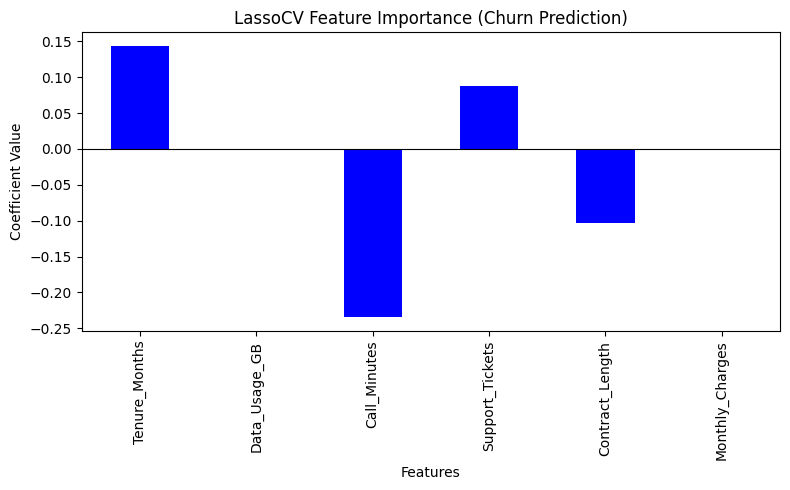

In [12]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
import matplotlib.pyplot as plt

# dataframe
data = {
    "Tenure_Months": [12, 3, 24, 6, 18],
    "Data_Usage_GB": [45, 12, 60, 20, 55],
    "Call_Minutes": [320, 110, 450, 200, 410],
    "Support_Tickets": [1, 4, 0, 3, 1],
    "Contract_Length": [24, 1, 24, 6, 12],
    "Monthly_Charges": [699, 499, 899, 599, 799],
    "Churn_Risk": [0.12, 0.78, 0.05, 0.55, 0.20]
}

df = pd.DataFrame(data)

x = df.drop("Churn_Risk", axis = 1)
y = df["Churn_Risk"]

#scaler_features
scaler = StandardScaler()
sca_pred = scaler.fit_transform(x)


#fit lasso_cv
lasso = LassoCV (cv = 3, random_state = 42)
lasso.fit(sca_pred, y)

# coef_
coef = pd.Series(lasso.coef_ ,index = x.columns)
print("lasso_coeffiect")
print(coef)

print("coefficent is not equal to zero")
print(coef[coef != 0])

#visulization

plt.figure(figsize=(8, 5))
coef.plot(kind="bar", color=["blue" if c != 0 else "red" for c in coef])
plt.title("LassoCV Feature Importance (Churn Prediction)")
plt.ylabel("Coefficient Value")
plt.xlabel("Features")
plt.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()


In [ ]:
# predicting house price

In [27]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

#create data_set

data = {
    'Size_sqft':[1200,800,1500,1000,1800],
    'Rooms':[3,2,4,3,5],
    'Distance_km':[5,12,3,8,2],
    'Area_Rating':[8,6,9,7,9],
    'Age_Years':[10,20,5,15,2],
    'Parking':[1,0,1,1,2],
    'Price_Lakhs':[85,45,120,65,150]
}

df = pd.DataFrame(data)

x = df.drop('Price_Lakhs', axis=1)
y = df['Price_Lakhs']

#features_scaling

scaler = StandardScaler()
x_scaler = scaler.fit_transform(x)

# train and test data

x_train, x_test, y_train, y_test = train_test_split(x_scaler, y, test_size = 0.4, random_state = 42)


#linear_regression

lin = LinearRegression()
lin.fit(x_train, y_train)
lin_pre = lin.predict(x_test)

print("linear_regression coef")
print("linear_coefficent: ", lin.coef_)
print("linear_intercept: ", lin.intercept_)
print("linear_MSR: ", np.sqrt(mean_squared_error(y_test, lin_pre)))
print("linear_r2 scores: ", r2_score(y_test, lin_pre ))
print("-"*50)

#lasso regression

lasso = LassoCV( cv = 3, random_state = 42)
lasso.fit(x_train, y_train)
lasso_pre = lasso.predict(x_test)

print("lassoCV")
print("lasso_coefficent: ", lasso.coef_)
print("lasso_intercept: ", lasso.intercept_)
print("lasso_MSR: ", np.sqrt(mean_squared_error(y_test, lin_pre)))
print("lasso_r2 scores: ", r2_score(y_test, lasso_pre ))
print("-"*50)


# compare features importance
feature_name =x.columns
feature_coef = pd.DataFrame({
    "feature": feature_name,
    "linear_coef": lin.coef_,
    "lasso_coef" : lasso.coef_
    })
print(feature_coef)

# Show actual vs predicted prices for Linear Regression
print("Actual vs Predicted (Linear Regression)")
comparison_lin = pd.DataFrame({
    "Actual Price (Lakhs)": y_test.values,
    "Predicted Price (Lakhs)": lin_pre
})
print(comparison_lin)
print("-"*50)

# Show actual vs predicted prices for Lasso Regression
print("Actual vs Predicted (Lasso Regression)")
comparison_lasso = pd.DataFrame({
    "Actual Price (Lakhs)": y_test.values,
    "Predicted Price (Lakhs)": lasso_pre
})
print(comparison_lasso)
print("-"*50)

linear_regression coef
linear_coefficent:  [ 9.02045862 13.7230935  -3.61066384  7.74975166 -6.9202      0.        ]
linear_intercept:  89.158181024706
linear_MSR:  10.757771414640393
linear_r2 scores:  0.9580119198876539
--------------------------------------------------
lassoCV
lasso_coefficent:  [ 3.56128143e+01  4.95656240e+00 -0.00000000e+00  1.50161055e-04
 -0.00000000e+00  0.00000000e+00]
lasso_intercept:  92.99516463711447
lasso_MSR:  10.757771414640393
lasso_r2 scores:  0.9913771786624034
--------------------------------------------------
       feature  linear_coef  lasso_coef
0    Size_sqft     9.020459   35.612814
1        Rooms    13.723094    4.956562
2  Distance_km    -3.610664   -0.000000
3  Area_Rating     7.749752    0.000150
4    Age_Years    -6.920200   -0.000000
5      Parking     0.000000    0.000000
Actual vs Predicted (Linear Regression)
   Actual Price (Lakhs)  Predicted Price (Lakhs)
0                    45                30.549597
1                   150     

In [ ]:
# medical 

linear regression [0.72137213 0.85420159]
MSE: 0.01641473134533461
r2_score: 0.8325583490380983
Ridge regression [0.71894226 0.85092435]
MSE: 0.015991042375941122
r2_score: 0.8069124855028931
lasso regression [0.72553488 0.83003662]
MSE: 0.02221424849006981
r2_score: 0.8005843023193022
  feature name    linear     ridge         lasso
0          Age  0.032050  0.031815  8.322211e-02
1          BMI  0.032050  0.031815  5.812083e-15
2           BP  0.032416  0.032235  5.885283e-02
3  Cholesterol  0.032634  0.032430  0.000000e+00
4      Glucose  0.032042  0.031876  1.139214e-02
5      Smoking  0.028251  0.028166  3.712611e-02


ValueError: Unrecognized marker style 'a'

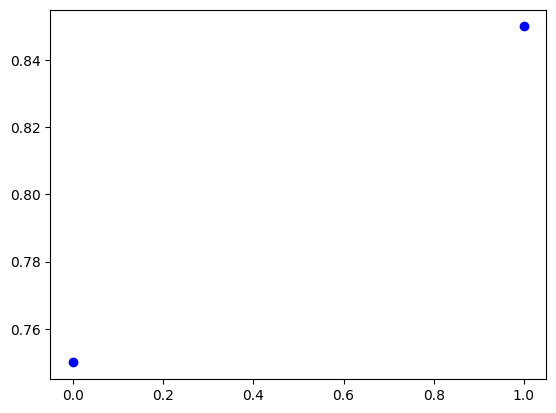

In [7]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# create a dataset

data = {
    "Age": [45, 60, 35, 50, 65],
    "BMI": [26, 30, 22, 28, 32],
    "BP": [120, 140, 110, 135, 145],
    "Cholesterol": [190, 230, 170, 210, 250],
    "Glucose": [95, 130, 85, 115, 140],
    "Smoking": [0, 1, 0, 1, 1],
    "Risk_Score": [0.30, 0.75, 0.10, 0.55, 0.85]
}

df = pd.DataFrame(data)

x = df.drop("Risk_Score", axis = 1)
y = df["Risk_Score"]

# train test split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.4, random_state = 42)

# features scaling

scal = StandardScaler()
x_train = scal.fit_transform(x_train)
x_test = scal.transform(x_test)


# linear fit model

lin = LinearRegression()
lin.fit(x_train, y_train)
lin_pre = lin.predict(x_test)
print("linear regression",lin_pre)
mse_lin = mean_absolute_error(y_test, lin_pre)
print("MSE:", mse_lin)
r2_lie = r2_score(y_test, lin_pre)
print("r2_score:", r2_lie)


#ridgeCV
rid = RidgeCV(cv = None)
rid.fit(x_train, y_train)
rid_pre = rid.predict(x_test)
print("Ridge regression",rid_pre)
mse_rid = mean_absolute_error(y_test, rid_pre)
print("MSE:", mse_rid)
r2_rid = r2_score(y_test, rid_pre)
print("r2_score:", r2_rid)

#lassoCV
las = LassoCV(cv = 3)
las.fit(x_train, y_train)
las_pre = las.predict(x_test)
print("lasso regression",las_pre)
mse_las = mean_absolute_error(y_test, las_pre)
print("MSE:", mse_las)
r2_las = r2_score(y_test, las_pre)
print("r2_score:", r2_las)


#features dataframe

features_name = x.columns
coef = pd.DataFrame({
    "feature name": features_name,
    "linear": lin.coef_,
    "ridge": rid.coef_,
    "lasso": las.coef_
})
print(coef)

#vasulization

plt.scatter(range(len(y_test)), y_test, color = "blue", label = "data")
plt.plot(range(len(y_test)), lin_pre , marker="a", color = "red", label = "linear")
plt.plot(range(len(y_test)), rid_pre, marker= "b",color = "green", label = "ridge")
plt.plot(range(len(y_test)), las_pre, marker= "c", color = "yellow" , label ="lasso")
plt.xlabel("actual_data")
plt.ylabel("predict")
plt.title("medical case")
plt.legend()
plt.show()
